# Model Evaluation Score Dashboard

**Audience**: Executives, managers, and business decision-makers  
**Purpose**: Communicate where models succeed and fail across evaluation categories — without statistical jargon.

This notebook is the communication layer: it shows **what** the numbers say and **so what** that means for decisions. It does not explain how scores were computed or which tests were run.

---

### How to use this notebook
1. Run **all cells** top-to-bottom once to generate the full dashboard.
2. Use the filter variables in **Section 1** to drill into specific models, categories, or date ranges.
3. Re-run the affected section cells to refresh the chart.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#F8F9FA",
    "axes.facecolor":    "#FFFFFF",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#E5E7EB",
    "grid.linewidth":    0.8,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
})

MODEL_COLORS = {
    "model-v1": "#6366F1",   # indigo
    "model-v2": "#10B981",   # emerald
    "model-v3": "#F59E0B",   # amber
}

CATEGORY_ORDER = [
    "reasoning",
    "knowledge",
    "code",
    "instruction_following",
    "tool_calling",
]

CATEGORY_LABELS = {
    "reasoning":             "Reasoning",
    "knowledge":             "Knowledge",
    "code":                  "Code",
    "instruction_following": "Instruction Following",
    "tool_calling":          "Tool Calling",
}

print("Setup complete.")

Setup complete.


## Section 1 — Load data & interactive filters

**Edit the variables below to filter the dashboard.**

In [2]:
# ── Load ───────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv("evaluation_data.csv", parse_dates=["date"])

# ── FILTERS — change these to drill into specific slices ───────────────────────
FILTER_MODELS     = None          # e.g. ["model-v2", "model-v3"]  or None for all
FILTER_CATEGORIES = None          # e.g. ["reasoning", "code"]     or None for all
FILTER_DATE_START = None          # e.g. "2025-03-01"               or None
FILTER_DATE_END   = None          # e.g. "2025-05-31"               or None

# ── Apply filters ──────────────────────────────────────────────────────────────
df = df_raw.copy()

if FILTER_MODELS:
    df = df[df["model_version"].isin(FILTER_MODELS)]
if FILTER_CATEGORIES:
    df = df[df["category"].isin(FILTER_CATEGORIES)]
if FILTER_DATE_START:
    df = df[df["date"] >= FILTER_DATE_START]
if FILTER_DATE_END:
    df = df[df["date"] <= FILTER_DATE_END]

# Keep only categories in canonical order that are still present
active_categories = [c for c in CATEGORY_ORDER if c in df["category"].unique()]
active_models     = sorted(df["model_version"].unique())

print(f"Rows loaded  : {len(df_raw):,}")
print(f"Rows in view : {len(df):,}")
print(f"Models       : {active_models}")
print(f"Categories   : {active_categories}")
print(f"Date range   : {df['date'].min().date()} → {df['date'].max().date()}")

Rows loaded  : 1,200
Rows in view : 1,200
Models       : ['model-v1', 'model-v2', 'model-v3']
Categories   : ['reasoning', 'knowledge', 'code', 'instruction_following', 'tool_calling']
Date range   : 2025-01-01 → 2025-05-31


## Section 2 — KPI summary cards

At-a-glance numbers for stakeholders who only have 30 seconds.

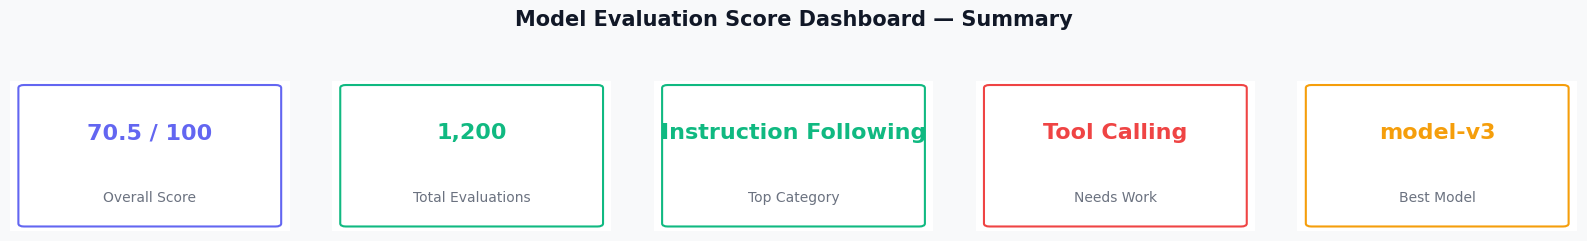

Figure saved: dashboard_kpi_cards.png


In [3]:
overall_avg   = df["score"].mean()
total_evals   = len(df)
best_category = df.groupby("category")["score"].mean().idxmax()
weak_category = df.groupby("category")["score"].mean().idxmin()
best_model    = df.groupby("model_version")["score"].mean().idxmax()

fig, axes = plt.subplots(1, 5, figsize=(16, 2.2))
fig.patch.set_facecolor("#F8F9FA")

kpis = [
    ("Overall Score",    f"{overall_avg:.1f} / 100", "#6366F1"),
    ("Total Evaluations",f"{total_evals:,}",          "#10B981"),
    ("Top Category",     CATEGORY_LABELS[best_category], "#10B981"),
    ("Needs Work",       CATEGORY_LABELS[weak_category], "#EF4444"),
    ("Best Model",       best_model,                    "#F59E0B"),
]

for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.65, value, ha="center", va="center",
            fontsize=16, fontweight="bold", color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha="center", va="center",
            fontsize=10, color="#6B7280",
            transform=ax.transAxes)
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.05, 0.05), 0.9, 0.9,
        boxstyle="round,pad=0.02",
        linewidth=1.5, edgecolor=color,
        facecolor="white",
        transform=ax.transAxes, clip_on=False
    ))

fig.suptitle("Model Evaluation Score Dashboard — Summary",
             fontsize=15, fontweight="bold", y=1.08, color="#111827")
plt.tight_layout()
plt.savefig("dashboard_kpi_cards.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: dashboard_kpi_cards.png")

## Section 3 — Score distribution (overall)

How scores spread across the full evaluation set. Peaks to the right are good; a long left tail flags systematic failures.

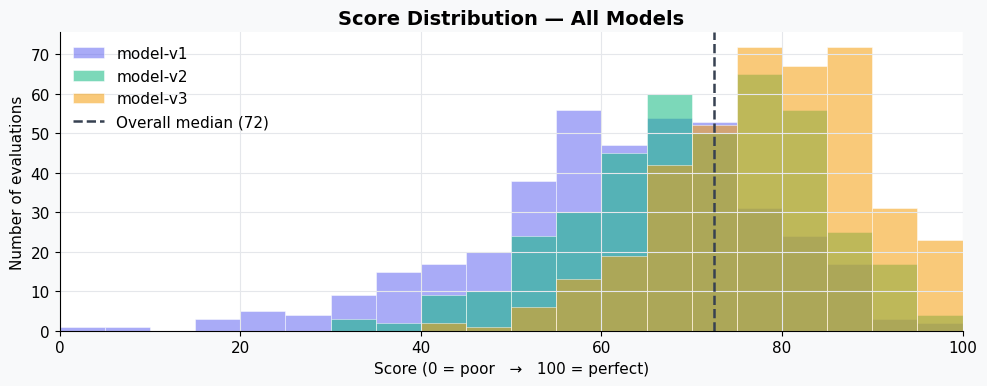

Figure saved: dashboard_score_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

bins = np.arange(0, 105, 5)

for model in active_models:
    data = df.loc[df["model_version"] == model, "score"]
    ax.hist(
        data, bins=bins,
        alpha=0.55,
        color=MODEL_COLORS.get(model, "#9CA3AF"),
        label=model,
        edgecolor="white",
        linewidth=0.6,
    )

# Overall median line
median_score = df["score"].median()
ax.axvline(median_score, color="#374151", linewidth=1.8, linestyle="--", label=f"Overall median ({median_score:.0f})")

ax.set_xlabel("Score (0 = poor   →   100 = perfect)")
ax.set_ylabel("Number of evaluations")
ax.set_title("Score Distribution — All Models")
ax.legend(frameon=False)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig("dashboard_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: dashboard_score_distribution.png")

## Section 4 — Score distribution by category

Box plots show the spread within each category. The line inside each box is the median. Shorter boxes = more consistent results.

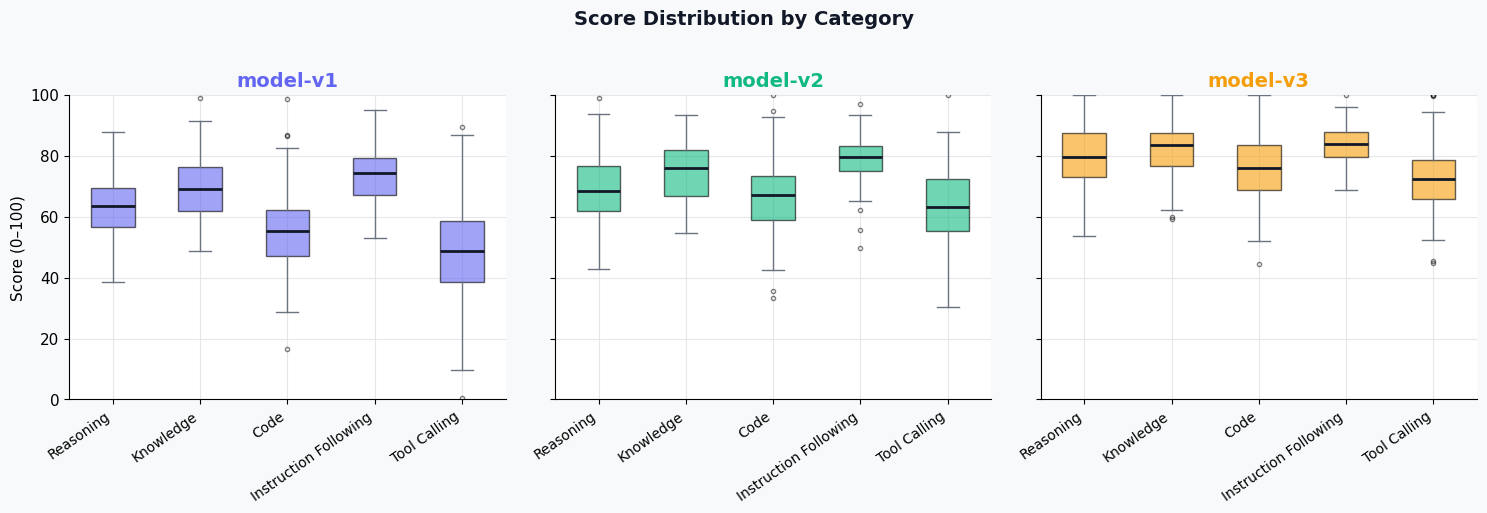

Figure saved: dashboard_scores_by_category.png


In [5]:
fig, axes = plt.subplots(
    1, len(active_models),
    figsize=(5 * len(active_models), 5),
    sharey=True,
)

if len(active_models) == 1:
    axes = [axes]

cat_labels = [CATEGORY_LABELS[c] for c in active_categories]

for ax, model in zip(axes, active_models):
    model_data = df[df["model_version"] == model]
    data_per_cat = [
        model_data.loc[model_data["category"] == cat, "score"].values
        for cat in active_categories
    ]

    bp = ax.boxplot(
        data_per_cat,
        patch_artist=True,
        medianprops=dict(color="#111827", linewidth=2),
        whiskerprops=dict(color="#6B7280"),
        capprops=dict(color="#6B7280"),
        flierprops=dict(marker="o", color="#9CA3AF", markersize=3, alpha=0.5),
    )
    color = MODEL_COLORS.get(model, "#9CA3AF")
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_xticks(range(1, len(active_categories) + 1))
    ax.set_xticklabels(cat_labels, rotation=35, ha="right", fontsize=10)
    ax.set_title(model, color=color)
    ax.set_ylim(0, 100)

axes[0].set_ylabel("Score (0–100)")
fig.suptitle("Score Distribution by Category",
             fontsize=14, fontweight="bold", color="#111827", y=1.02)

plt.tight_layout()
plt.savefig("dashboard_scores_by_category.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: dashboard_scores_by_category.png")

## Section 5 — Category performance comparison

Average score per category, sorted from highest to lowest. Use this to prioritise which areas need attention.

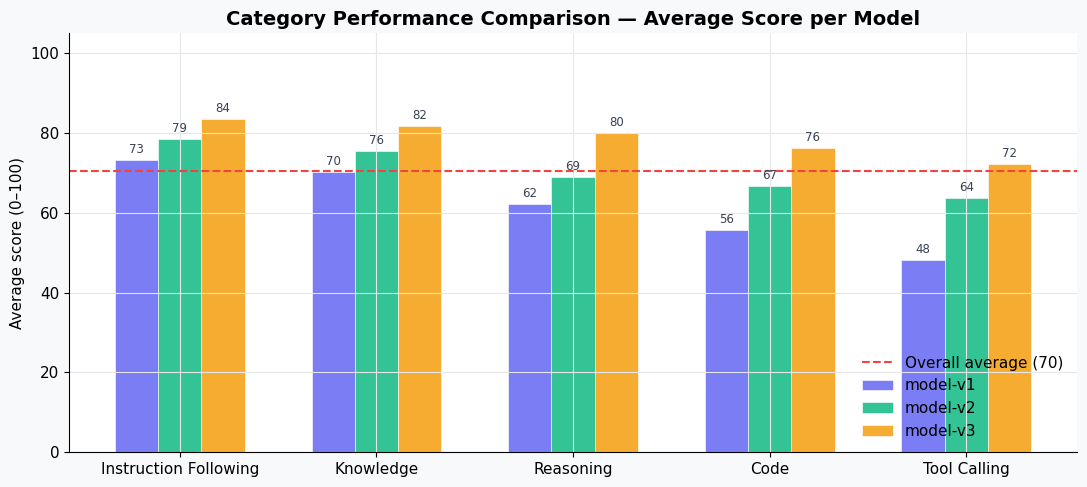

Figure saved: dashboard_category_comparison.png


In [6]:
avg = (
    df.groupby(["category", "model_version"])["score"]
    .mean()
    .reset_index()
    .rename(columns={"score": "avg_score"})
)

# Sort categories by overall average (descending)
cat_order = (
    avg.groupby("category")["avg_score"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

n_cats   = len(cat_order)
n_models = len(active_models)
x        = np.arange(n_cats)
width    = 0.22
offsets  = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

fig, ax = plt.subplots(figsize=(11, 5))

overall_avg_per_cat = avg.groupby("category")["avg_score"].mean().reindex(cat_order).values

for i, model in enumerate(active_models):
    model_avgs = avg[avg["model_version"] == model].set_index("category")["avg_score"]
    scores = [model_avgs.get(c, np.nan) for c in cat_order]
    bars = ax.bar(
        x + offsets[i], scores,
        width=width,
        label=model,
        color=MODEL_COLORS.get(model, "#9CA3AF"),
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
    )
    # Data labels
    for bar, score in zip(bars, scores):
        if not np.isnan(score):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{score:.0f}",
                ha="center", va="bottom",
                fontsize=8.5, color="#374151"
            )

# Overall average benchmark line
grand_avg = df["score"].mean()
ax.axhline(grand_avg, color="#EF4444", linewidth=1.5,
           linestyle="--", label=f"Overall average ({grand_avg:.0f})")

ax.set_xticks(x)
ax.set_xticklabels([CATEGORY_LABELS[c] for c in cat_order], fontsize=11)
ax.set_ylabel("Average score (0–100)")
ax.set_ylim(0, 105)
ax.set_title("Category Performance Comparison — Average Score per Model")
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("dashboard_category_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: dashboard_category_comparison.png")

## Section 6 — Performance heatmap

At a glance: green = strong, red = needs improvement. Each cell shows the average score for that model × category combination.

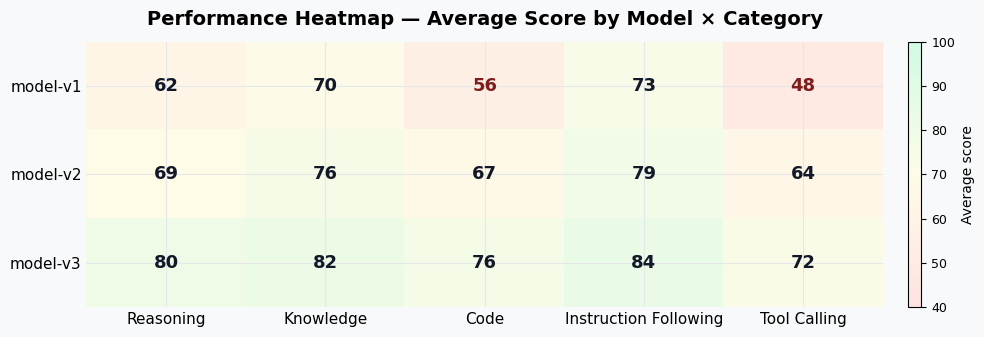

Figure saved: dashboard_heatmap.png


In [7]:
pivot = (
    df.groupby(["model_version", "category"])["score"]
    .mean()
    .unstack("category")
    .reindex(columns=active_categories)
)

cmap = LinearSegmentedColormap.from_list(
    "rg", ["#FEE2E2", "#FEFCE8", "#D1FAE5"], N=256
)

fig, ax = plt.subplots(figsize=(10, 3.5))

im = ax.imshow(pivot.values, cmap=cmap, vmin=40, vmax=100, aspect="auto")

ax.set_xticks(range(len(active_categories)))
ax.set_xticklabels([CATEGORY_LABELS[c] for c in active_categories], fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

for r, model in enumerate(pivot.index):
    for c, cat in enumerate(active_categories):
        val = pivot.loc[model, cat]
        text_color = "#111827" if val > 60 else "#7F1D1D"
        ax.text(c, r, f"{val:.0f}",
                ha="center", va="center",
                fontsize=13, fontweight="bold", color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
cbar.set_label("Average score", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title("Performance Heatmap — Average Score by Model × Category",
             fontsize=14, fontweight="bold", pad=12)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("dashboard_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: dashboard_heatmap.png")

## Section 7 — Score trend over time

Monthly average scores per model. An upward trend shows improvement; a flat or declining line flags a regression.

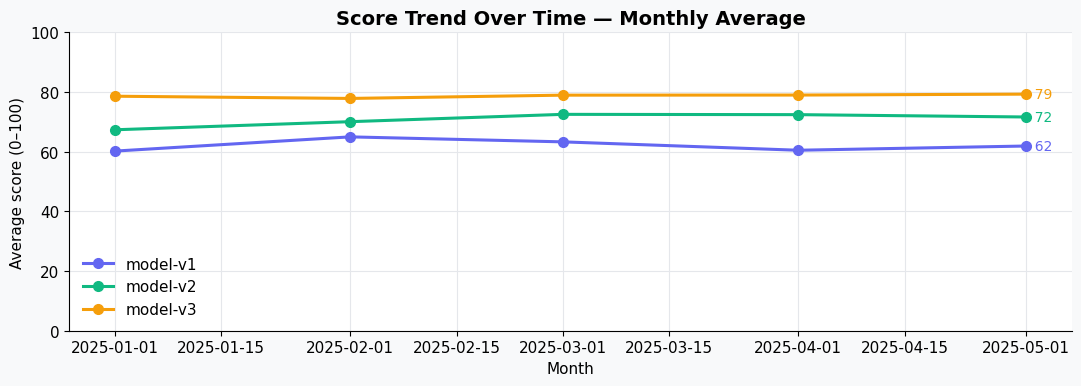

Figure saved: dashboard_trend.png


In [8]:
df_time = df.copy()
df_time["month"] = df_time["date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df_time.groupby(["month", "model_version"])["score"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 4))

for model in active_models:
    sub = monthly[monthly["model_version"] == model].sort_values("month")
    color = MODEL_COLORS.get(model, "#9CA3AF")
    ax.plot(
        sub["month"], sub["score"],
        marker="o", markersize=7,
        linewidth=2.2, color=color,
        label=model,
    )
    # Annotate last point
    last = sub.iloc[-1]
    ax.annotate(
        f"  {last['score']:.0f}",
        xy=(last["month"], last["score"]),
        fontsize=10, color=color, va="center",
    )

ax.set_xlabel("Month")
ax.set_ylabel("Average score (0–100)")
ax.set_title("Score Trend Over Time — Monthly Average")
ax.legend(frameon=False)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("dashboard_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: dashboard_trend.png")

## Section 8 — Combined dashboard (single-page export)

All five charts on one canvas — suitable for a screenshot or PDF export to share with stakeholders.

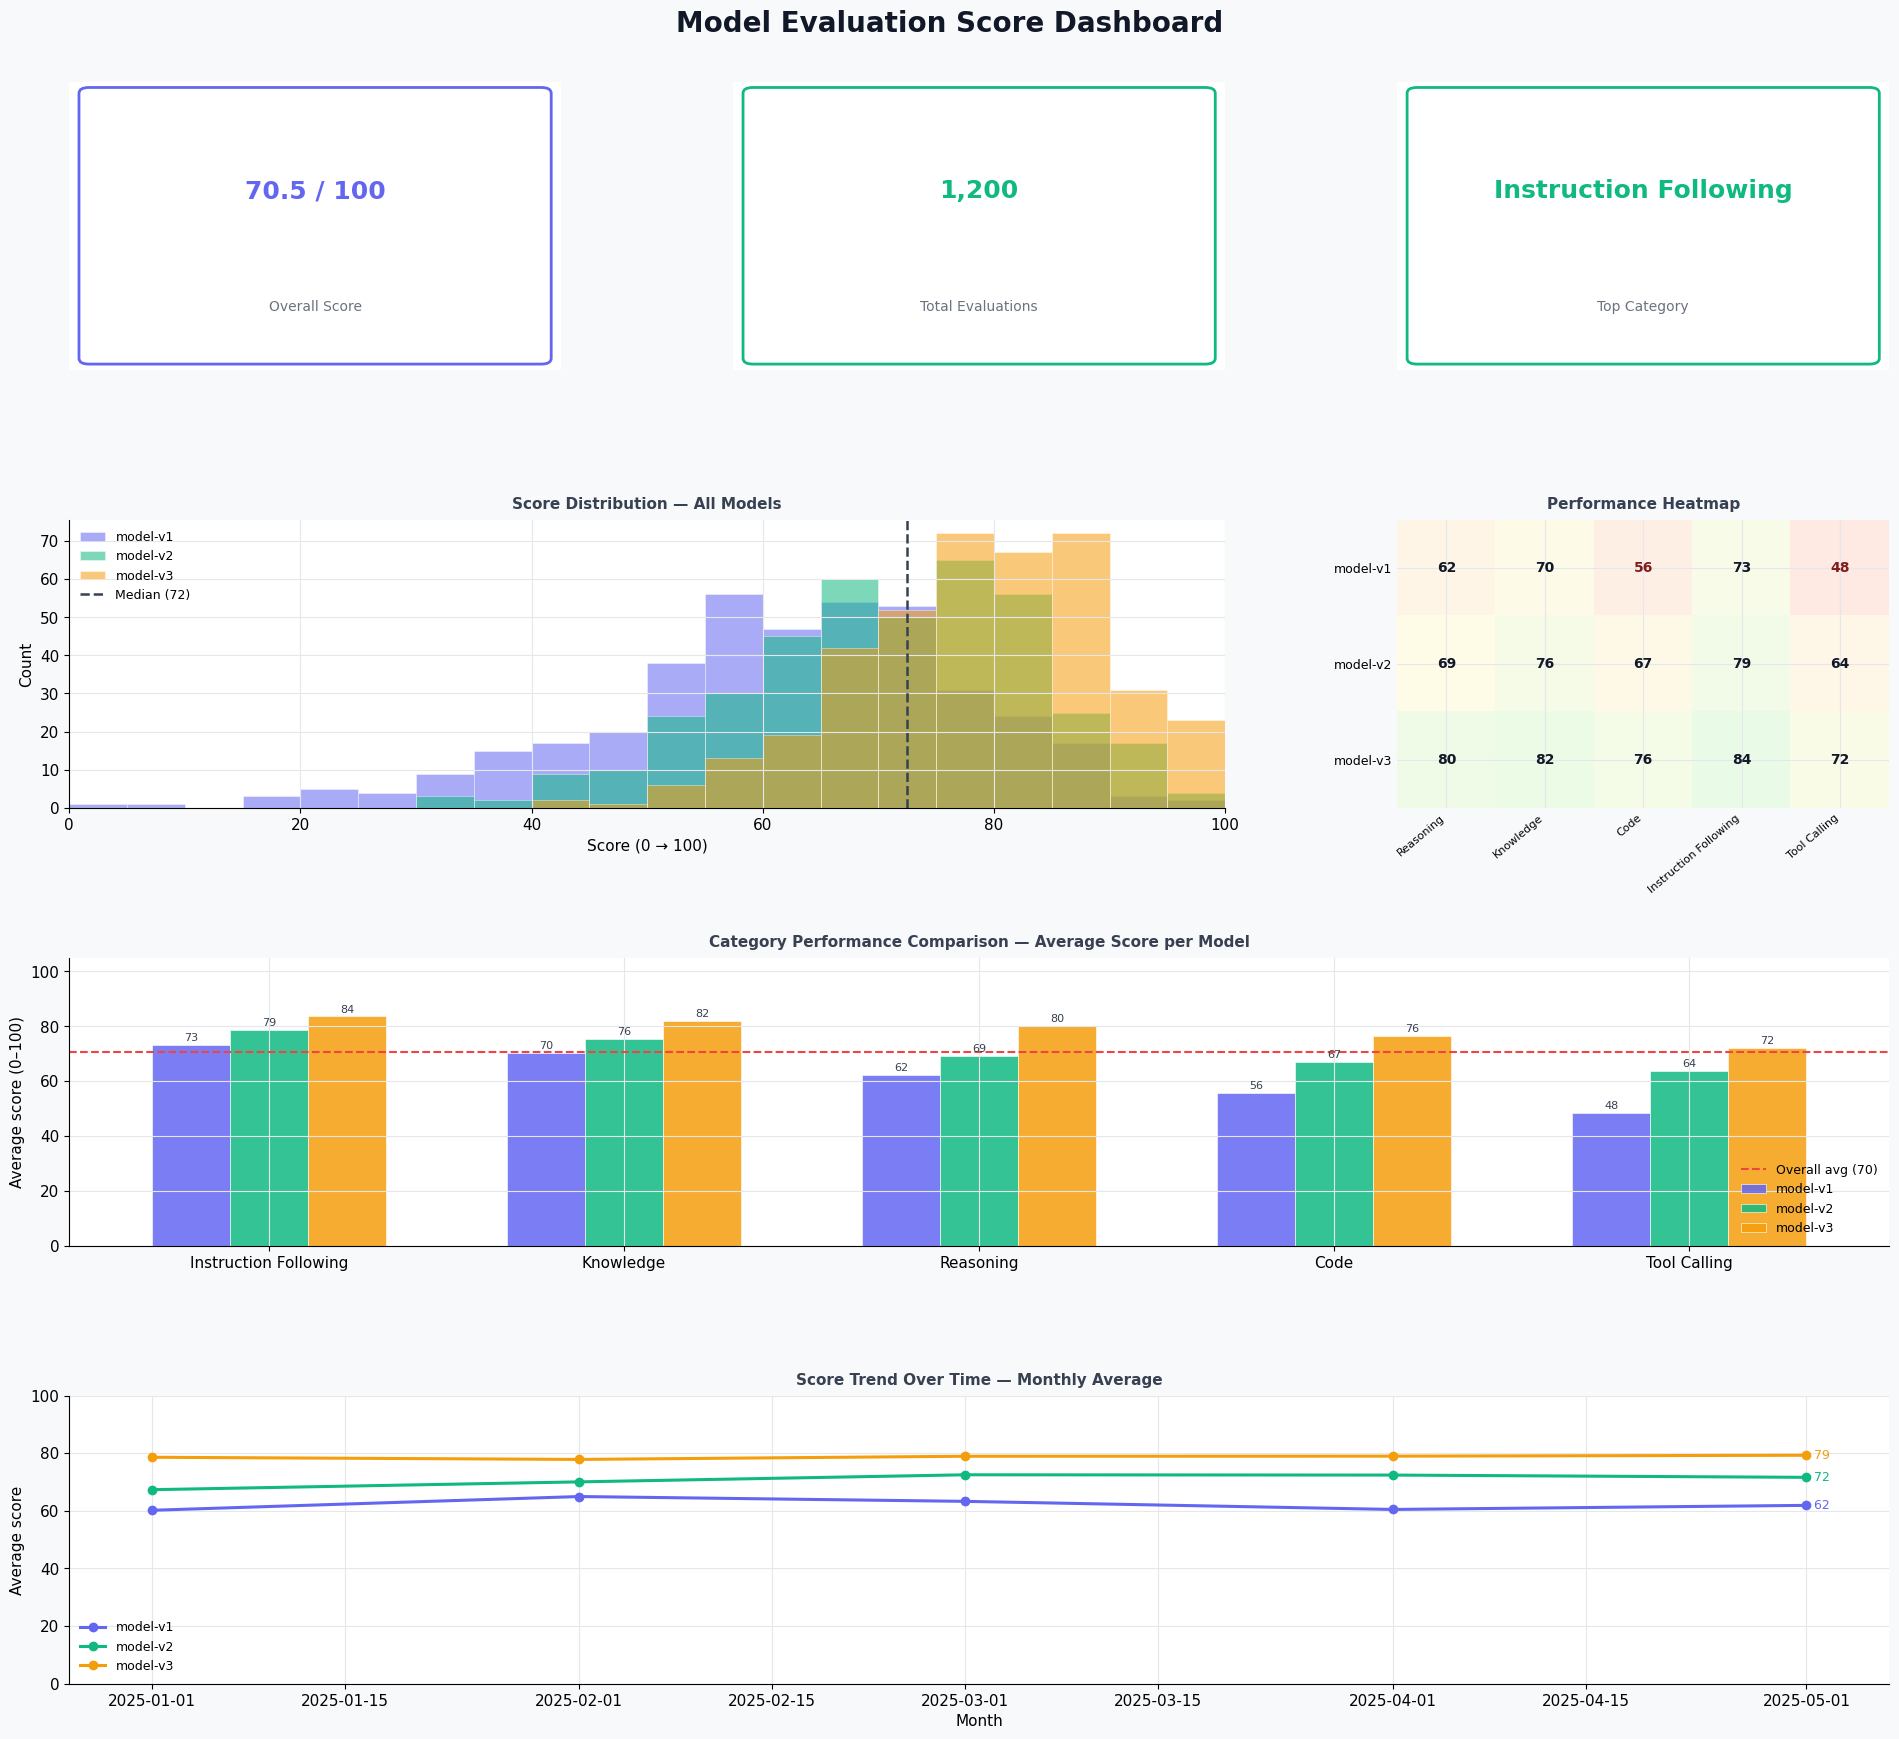

Dashboard saved: dashboard_screenshot.png


In [9]:
fig = plt.figure(figsize=(20, 18), facecolor="#F8F9FA")
fig.suptitle(
    "Model Evaluation Score Dashboard",
    fontsize=20, fontweight="bold", color="#111827", y=0.98
)

gs = gridspec.GridSpec(
    4, 3, figure=fig,
    hspace=0.52, wspace=0.35,
    top=0.94, bottom=0.05, left=0.06, right=0.97
)

# ── Helpers ────────────────────────────────────────────────────────────────────
def style_ax(ax, title):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, color="#E5E7EB", linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8, color="#374151")

# ── Row 0: KPI cards ──────────────────────────────────────────────────────────
kpi_labels = [
    ("Overall Score",      f"{df['score'].mean():.1f} / 100",    "#6366F1"),
    ("Total Evaluations",  f"{len(df):,}",                        "#10B981"),
    ("Top Category",       CATEGORY_LABELS[df.groupby('category')['score'].mean().idxmax()], "#10B981"),
    ("Needs Work",         CATEGORY_LABELS[df.groupby('category')['score'].mean().idxmin()], "#EF4444"),
    ("Best Model",         df.groupby('model_version')['score'].mean().idxmax(), "#F59E0B"),
    ("Date Range",         f"{df['date'].min().strftime('%b %Y')} – {df['date'].max().strftime('%b %Y')}", "#6B7280"),
]

for col, (label, value, color) in enumerate(kpi_labels[:3]):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor("white")
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.62, value, ha="center", va="center",
            fontsize=18, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha="center", va="center",
            fontsize=10, color="#6B7280", transform=ax.transAxes)
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.04, 0.04), 0.92, 0.92, boxstyle="round,pad=0.02",
        linewidth=2, edgecolor=color, facecolor="white",
        transform=ax.transAxes, clip_on=False
    ))

# ── Row 1 left-center: Score distribution ─────────────────────────────────────
ax1 = fig.add_subplot(gs[1, :2])
style_ax(ax1, "Score Distribution — All Models")
bins = np.arange(0, 105, 5)
for model in active_models:
    data = df.loc[df["model_version"] == model, "score"]
    ax1.hist(data, bins=bins, alpha=0.55,
             color=MODEL_COLORS.get(model, "#9CA3AF"),
             label=model, edgecolor="white", linewidth=0.5)
ax1.axvline(df["score"].median(), color="#374151", linewidth=1.8,
            linestyle="--", label=f"Median ({df['score'].median():.0f})")
ax1.set_xlabel("Score (0 → 100)")
ax1.set_ylabel("Count")
ax1.set_xlim(0, 100)
ax1.legend(frameon=False, fontsize=9)

# ── Row 1 right: Heatmap ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2])
style_ax(ax2, "Performance Heatmap")
pivot = (
    df.groupby(["model_version", "category"])["score"]
    .mean().unstack("category").reindex(columns=active_categories)
)
im = ax2.imshow(pivot.values, cmap=cmap, vmin=40, vmax=100, aspect="auto")
ax2.set_xticks(range(len(active_categories)))
ax2.set_xticklabels([CATEGORY_LABELS[c] for c in active_categories],
                    rotation=40, ha="right", fontsize=8)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index, fontsize=9)
for r, m in enumerate(pivot.index):
    for c, cat in enumerate(active_categories):
        val = pivot.loc[m, cat]
        ax2.text(c, r, f"{val:.0f}", ha="center", va="center",
                 fontsize=10, fontweight="bold",
                 color="#111827" if val > 60 else "#7F1D1D")
ax2.tick_params(length=0)
for sp in ax2.spines.values(): sp.set_visible(False)

# ── Row 2: Category comparison ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :])
style_ax(ax3, "Category Performance Comparison — Average Score per Model")
avg = (
    df.groupby(["category", "model_version"])["score"]
    .mean().reset_index().rename(columns={"score": "avg_score"})
)
cat_order_local = (
    avg.groupby("category")["avg_score"]
    .mean().sort_values(ascending=False).index.tolist()
)
x = np.arange(len(cat_order_local))
offsets_local = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * 0.22
for i, model in enumerate(active_models):
    m_avg = avg[avg["model_version"] == model].set_index("category")["avg_score"]
    scores = [m_avg.get(c, np.nan) for c in cat_order_local]
    bars = ax3.bar(x + offsets_local[i], scores, width=0.22,
                   label=model, color=MODEL_COLORS.get(model, "#9CA3AF"),
                   alpha=0.85, edgecolor="white", linewidth=0.5)
    for bar, sc in zip(bars, scores):
        if not np.isnan(sc):
            ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                     f"{sc:.0f}", ha="center", va="bottom", fontsize=8, color="#374151")
ax3.axhline(df["score"].mean(), color="#EF4444", linewidth=1.5,
            linestyle="--", label=f"Overall avg ({df['score'].mean():.0f})")
ax3.set_xticks(x)
ax3.set_xticklabels([CATEGORY_LABELS[c] for c in cat_order_local], fontsize=11)
ax3.set_ylabel("Average score (0–100)")
ax3.set_ylim(0, 105)
ax3.legend(frameon=False, fontsize=9, loc="lower right")

# ── Row 3: Trend ──────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3, :])
style_ax(ax4, "Score Trend Over Time — Monthly Average")
df_t = df.copy()
df_t["month"] = df_t["date"].dt.to_period("M").dt.to_timestamp()
monthly_local = (
    df_t.groupby(["month", "model_version"])["score"]
    .mean().reset_index()
)
for model in active_models:
    sub = monthly_local[monthly_local["model_version"] == model].sort_values("month")
    color = MODEL_COLORS.get(model, "#9CA3AF")
    ax4.plot(sub["month"], sub["score"],
             marker="o", markersize=6, linewidth=2.2,
             color=color, label=model)
    last = sub.iloc[-1]
    ax4.annotate(f"  {last['score']:.0f}",
                 xy=(last["month"], last["score"]),
                 fontsize=9, color=color, va="center")
ax4.set_xlabel("Month")
ax4.set_ylabel("Average score")
ax4.set_ylim(0, 100)
ax4.legend(frameon=False, fontsize=9)

plt.savefig("dashboard_screenshot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved: dashboard_screenshot.png")

## Section 9 — Key findings for stakeholders

Plain-language summary. No formulas, no test names — just conclusions and recommended actions.

In [10]:
# Compute a concise findings summary
model_avgs  = df.groupby("model_version")["score"].mean().sort_values(ascending=False)
cat_avgs    = df.groupby("category")["score"].mean().sort_values(ascending=False)
below_70    = cat_avgs[cat_avgs < 70].index.tolist()

print("=" * 60)
print("KEY FINDINGS — Model Evaluation Score Dashboard")
print("=" * 60)

print("\n📊 Overall performance")
for model, avg in model_avgs.items():
    rank = list(model_avgs.index).index(model) + 1
    print(f"  #{rank} {model}: {avg:.1f} / 100")

print("\n✅ Strongest categories (top 2)")
for cat in cat_avgs.index[:2]:
    print(f"  {CATEGORY_LABELS[cat]}: {cat_avgs[cat]:.1f}")

print("\n⚠️  Categories below 70 (recommend investment)")
if below_70:
    for cat in below_70:
        print(f"  {CATEGORY_LABELS[cat]}: {cat_avgs[cat]:.1f}")
else:
    print("  All categories above 70 — no urgent gaps.")

print("\n💡 Recommended actions")
print(f"  1. Prioritise {CATEGORY_LABELS[cat_avgs.idxmin()]} improvements in the next sprint.")
print(f"  2. Use {model_avgs.idxmax()} as the production baseline.")
print(f"  3. Re-evaluate after the next fine-tuning run to confirm improvement.")

print("\n" + "=" * 60)
print("Note: Scores range from 0 (poor) to 100 (perfect).")
print(f"Data covers {df['date'].min().strftime('%B %Y')} – {df['date'].max().strftime('%B %Y')}.")

KEY FINDINGS — Model Evaluation Score Dashboard

📊 Overall performance
  #1 model-v3: 78.8 / 100
  #2 model-v2: 70.7 / 100
  #3 model-v1: 62.0 / 100

✅ Strongest categories (top 2)
  Instruction Following: 78.5
  Knowledge: 75.8

⚠️  Categories below 70 (recommend investment)
  Code: 66.3
  Tool Calling: 61.4

💡 Recommended actions
  1. Prioritise Tool Calling improvements in the next sprint.
  2. Use model-v3 as the production baseline.
  3. Re-evaluate after the next fine-tuning run to confirm improvement.

Note: Scores range from 0 (poor) to 100 (perfect).
Data covers January 2025 – May 2025.
